In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
sns.set_palette("colorblind")

# Configuration
DATA_DIR = Path('folktables_results')
OUTPUT_DIR = Path('plots')
TASKS = ['income']
N_SEEDS = 3
THRESHOLD = 0.10  # 10% difference threshold

In [2]:
STATES = ['CA', 'TX', 'FL', 'NY']
MODELS = ['LR', 'GBM', 'GBM_tun', 'GBM_opt']

In [3]:
model_dict = {'LR': 'LR', 'GBM': 'GBM (coarse)' , 'GBM_tun': 'GBM (tuned)', 'GBM_opt': 'GBM (fine)'}

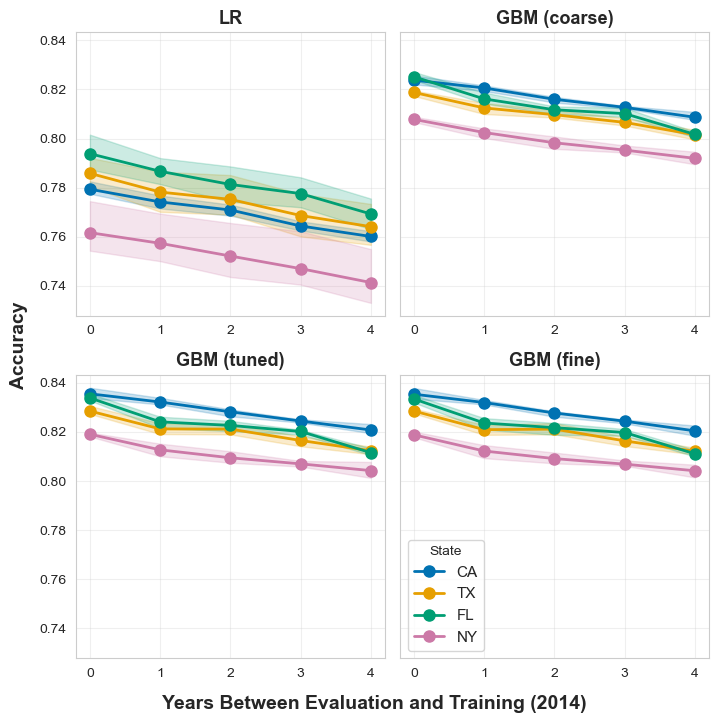

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7), sharey=True)
axes_flat = axes.flatten()
colors = ['#0072B2', '#E69F00', '#009E73', '#CC79A7']

for j, model in enumerate(MODELS):
    ax = axes_flat[j]
    
    for i, state in enumerate(STATES):
        data = pd.read_csv(DATA_DIR / f"exp_a_{state}_income_{model}.csv")
        
        summary = data.groupby('eval_year')['accuracy'].agg(['mean', 'min', 'max']).reset_index()
        summary['years_from_train'] = summary['eval_year'] - 2014
        
        ax.plot(summary['years_from_train'], summary['mean'], color=colors[i],
                marker='o', label=state, linewidth=2, markersize=8)
        ax.fill_between(summary['years_from_train'], 
                        summary['min'],
                        summary['max'], 
                        color=colors[i],
                        alpha=0.2)
    
    ax.set_title(model_dict[model], fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0, 1, 2, 3, 4])

    # Only show legend in the last plot
    if j == len(MODELS) - 1:
        ax.legend(title='State', loc='best', fontsize='11')

# axis descriptions
fig.text(0.5, -0.02, 'Years Between Evaluation and Training (2014)', ha='center', fontsize=14, fontweight='bold')
fig.text(-0.02, 0.5, 'Accuracy', va='center', rotation='vertical', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'exp_a_degradation.pdf', bbox_inches='tight')
plt.show()